# Logistic Regression from Scratch: Gradient Descent on the Titanic Dataset

This notebook reimplements logistic regression example from Part 1, but instead of calling `LogisticRegression().fit()`,
we derive and implement **gradient descent** by hand.

We will:
1. Load and preprocess the Titanic dataset.
2. Review the mathematical foundations of logistic regression.
3. Implement gradient descent to learn the model weights.
4. Compare our results against scikit-learn.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

sys.path.insert(0, '..')
from src.logreg import logistic_regression_gd, predict, accuracy

## 1. Data Loading and Preprocessing

In [2]:
data = pd.read_csv("../data/titanic.csv")
data.head()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


In [3]:
FEATURES = ["sex", "age", "family_size", "fare", "1st_class", "2nd_class", "3rd_class"]
TARGET = "survived"
numerical_cols = ['age', 'fare', 'family_size']

features = data[FEATURES]
target = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=81842, stratify=target
)
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Training set: 709 samples, Test set: 178 samples


## 2. Feature Standardization

Gradient descent converges much faster when features are on a similar scale.
We standardize each feature to have zero mean and unit variance:

$$
x_j^{\prime} = \frac{x_j - \mu_j}{\sigma_j}
$$

We fit the statistics on the **training set only** and apply them to both sets
to avoid data leakage.

In [4]:
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

train_numerical = X_train_clean[numerical_cols].to_numpy()
means = np.mean(train_numerical, axis=0)
stds = np.std(train_numerical, axis=0)

X_train_clean[numerical_cols] = (train_numerical - means) / stds

test_numerical = X_test_clean[numerical_cols].to_numpy()
X_test_clean[numerical_cols] = (test_numerical - means) / stds

scaler_stats = pd.DataFrame({'Feature': numerical_cols, 'Mean (μ)': means, 'Std Dev (σ)': stds})
print("Scaler statistics (fitted on training set):")
print(scaler_stats.to_string(index=False))

X_train_s = X_train_clean.to_numpy()
y_train_s = y_train.to_numpy().reshape(-1, 1)

X_test_s = X_test_clean.to_numpy()
y_test_s = y_test.to_numpy().reshape(-1, 1)

Scaler statistics (fitted on training set):
    Feature  Mean (μ)  Std Dev (σ)
        age 29.669732    13.970112
       fare 31.592541    46.991252
family_size  0.892807     1.633506


## 3. Mathematical Background

### 3.1 The Logistic (Sigmoid) Function

In logistic regression we model the probability that a sample belongs to the
positive class ($y = 1$) using the **sigmoid function**:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

where the linear combination (logit) is:

$$
z = \mathbf{w}^\top \mathbf{x} + b = \sum_{j=1}^{d} w_j x_j + b
$$

Here $\mathbf{w} \in \mathbb{R}^d$ is the weight vector, $b \in \mathbb{R}$ is
the bias (intercept), and $d$ is the number of features.

The sigmoid function maps any real-valued input to a value between 0 and 1. 
We will use it to transform the model’s raw output (which can be any real number) into a probability. 
Large positive numbers are mapped close to 1, large negative numbers are mapped close to 0. 
This makes it suitable for binary classification.

The predicted probability is therefore:

$$
\hat{y} = P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)
$$

The model computes a weighted sum of the input features and adds a bias term. 
This linear combination represents how strongly the input features support one class over the other. 
The sigmoid function then converts this value into a probability.

For example, a value of 0.8 means that the model estimated an 80% chance that the input belongs to the positive class.

### 3.2 Binary Cross-Entropy Loss

We measure how well the model fits the training data using the
**binary cross-entropy** (log loss), averaged over $n$ samples:

$$
\mathcal{L}(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n}
\left[
  y^{(i)} \ln\!\big(\hat{y}^{(i)}\big)
  + \big(1 - y^{(i)}\big) \ln\!\big(1 - \hat{y}^{(i)}\big)
\right]
$$

This loss is **convex** in $\mathbf{w}$ and $b$, so gradient descent is
guaranteed to find the global minimum.

The loss function measures how well the model predictions (the probabilities) match the true labels.  
Binary cross-entropy penalizes confident but incorrect predictions more heavily than uncertain ones.
If the model predicts a probability close to the true label, the loss is small, otherwise the loss increases rapidly.

### 3.3 Gradient Derivation

To compute how the loss changes with respect to the model parameters, gradients tell us in which direction we need to adjust the parameters to reduce the loss.

If the predictions are too high, this will lead to gradients with positive values. 
If predictions are too low, this will lead to gradients with negative values. 
The magnitude depends on how large the error is and the value of the input features.

To minimize $\mathcal{L}$ we need the partial derivatives with respect to each weight $w_j$ and the bias $b$.

Using the chain rule and the identity
$\sigma'(z) = \sigma(z)(1 - \sigma(z))$, the gradients simplify to:

$$
\frac{\partial \mathcal{L}}{\partial w_j}
= \frac{1}{n} \sum_{i=1}^{n}
  \big(\hat{y}^{(i)} - y^{(i)}\big)\, x_j^{(i)}
$$

$$
\frac{\partial \mathcal{L}}{\partial b}
= \frac{1}{n} \sum_{i=1}^{n}
  \big(\hat{y}^{(i)} - y^{(i)}\big)
$$

Or in compact vector notation, with
$\hat{\mathbf{y}} = \sigma(X\mathbf{w} + b)$:

$$
\nabla_{\mathbf{w}} \mathcal{L}
= \frac{1}{n} X^\top (\hat{\mathbf{y}} - \mathbf{y})
\qquad\qquad
\frac{\partial \mathcal{L}}{\partial b}
= \frac{1}{n} \mathbf{1}^\top (\hat{\mathbf{y}} - \mathbf{y})
$$

### 3.4 Gradient Descent Update Rule

We iteratively update the parameters using a learning rate $\alpha$:

$$
\mathbf{w} \leftarrow \mathbf{w} - \alpha\, \nabla_{\mathbf{w}} \mathcal{L}
$$

$$
b \leftarrow b - \alpha\, \frac{\partial \mathcal{L}}{\partial b}
$$

At each step, the model updates the parameters slightly to reduce loss. Over many iterations, this leads to a set of parameters that fit the data well.

The learning rate $\alpha$ determines how large the update step is when adjusting the model parameters during training. 
Small learning rates (e.g. $\alpha = 0.001$) are slow but stable, whereas large learning rates ($\alpha = 0.1$) are fast, but may cause instabilities and training may fail completely.

We repeat until convergence (i.e., until the loss changes by less than a pre-defined tolerance $\varepsilon$), or if a maximum number of iterations is reached.

## 4. Implementation

The five components — `sigmoid`, `binary_cross_entropy`, `logistic_regression_gd`, `predict`, and `accuracy` — are implemented in `src/logreg.py` and imported at the top of this notebook. This keeps the functions testable and reusable outside the notebook.

## 5. Training

In [5]:
w, b, loss_history = logistic_regression_gd(X_train_s, y_train_s, lr=0.1, max_iter=1000)

print(f"Final loss: {loss_history[-1]:.6f}")
print(f"Iterations: {len(loss_history)}")
print(f"\nLearned weights:")
for name, weight in zip(FEATURES, w):
    print(f"  {name:>15s}: {weight[0]:+.4f}")
print(f"  {'bias':>15s}: {b:+.4f}")

Iter    0: loss=0.693147
Iter  100: loss=0.527189
Iter  200: loss=0.494847
Iter  300: loss=0.478472
Iter  400: loss=0.469233
Iter  500: loss=0.463700
Iter  600: loss=0.460245
Iter  700: loss=0.458019
Iter  800: loss=0.456548
Iter  900: loss=0.455556
Final loss: 0.454884
Iterations: 1000

Learned weights:
              sex: -2.4232
              age: -0.4439
      family_size: -0.3904
             fare: +0.1955
        1st_class: +1.2613
        2nd_class: +0.3577
        3rd_class: -0.6516
             bias: +0.9673


**Key Findings:**

* **The model ran for all 1000 iterations** without converging early, meaning the loss was still slowly improving at the end. A higher `max_iter` or larger learning rate could squeeze out a bit more.
* **Final loss of 0.455** — this is the binary cross-entropy on the training set. Lower is better, and we will check how it compares to sklearn in Section 7.
* **The weights make intuitive sense:** `sex` has the largest negative weight (being male reduces survival probability), `1st_class` is strongly positive, and `3rd_class` is negative — consistent with everything we found in the EDA.

### Loss Curve

A decreasing loss curve confirms that gradient descent is working correctly.

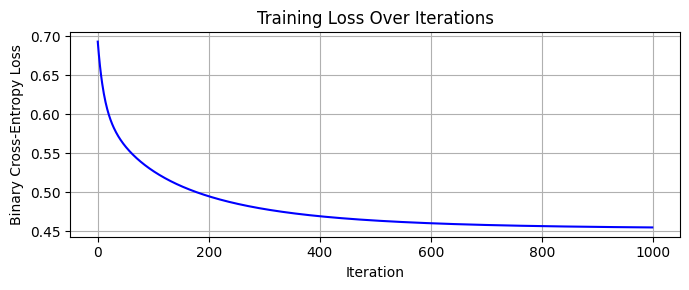

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))

ax.plot(loss_history, color='blue', label='Training Loss')

ax.set_title("Training Loss Over Iterations")
ax.set_xlabel("Iteration")
ax.set_ylabel("Binary Cross-Entropy Loss")
ax.grid(True)

plt.tight_layout()
plt.show()

## 6. Evaluation

We classify a sample as positive ($\hat{y} = 1$) when $\sigma(z) \geq 0.5$,
which is equivalent to $z \geq 0$.

In [7]:
y_pred_train = predict(X_train_s, w, b)
y_pred_test = predict(X_test_s, w, b)

print(f"Our model — Train accuracy: {accuracy(y_train_s, y_pred_train):.4f}")
print(f"Our model — Test accuracy:  {accuracy(y_test_s, y_pred_test):.4f}")

Our model — Train accuracy: 0.7941
Our model — Test accuracy:  0.8483


**Key Findings:**

* **Test accuracy of 0.848** — the model correctly predicts about 5 out of 6 passengers, which is a strong result for a hand-written implementation.
* **Beats the baseline** — a naive model that always predicts "not survived" would score ~61%, so our implementation is meaningfully better.
* **Train accuracy of 0.794 is lower than test accuracy** — this is a bit unusual but can happen with small datasets and a fixed random split.

## 7. Comparison with scikit-learn

We train the same model using scikit-learn's `LogisticRegression` (with the
same standardized data) to verify that our gradient descent implementation
arrives at comparable accuracy and weights.

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# scikit-learn logistic regression (no regularization, to match our implementation)
sk_model = LogisticRegression(max_iter=1000, random_state=42, C=np.inf)
sk_model.fit(X_train_s, y_train_s.ravel())

sk_accuracy = sk_model.score(X_test_s, y_test_s)
our_accuracy = accuracy(y_test_s, y_pred_test)

print(f"scikit-learn test accuracy: {sk_accuracy:.4f}")
print(f"Our GD test accuracy:      {our_accuracy:.4f}")
print()

# Compare learned weights
print(f"{'Feature':>20s} | {'Ours':>8s} | {'sklearn':>8s}")
print("-" * 45)
for name, w_ours, w_sk in zip(FEATURES, w, sk_model.coef_[0]):
    print(f"{name:>20s} | {w_ours[0]:+8.4f} | {w_sk:+8.4f}")
print(f"{'bias':>20s} | {b:+8.4f} | {sk_model.intercept_[0]:+8.4f}")
print("-" * 45)

scikit-learn test accuracy: 0.8483
Our GD test accuracy:      0.8483

             Feature |     Ours |  sklearn
---------------------------------------------
                 sex |  -2.4232 |  -2.6755
                 age |  -0.4439 |  -0.5081
         family_size |  -0.3904 |  -0.4151
                fare |  +0.1955 |  +0.1012
           1st_class |  +1.2613 |  +1.5441
           2nd_class |  +0.3577 |  +0.3311
           3rd_class |  -0.6516 |  -0.7534
                bias |  +0.9673 |  +1.1217
---------------------------------------------


**Key Findings:**

* **Same test accuracy (0.8483)** — our gradient descent implementation reaches exactly the same result as scikit-learn's optimized solver on this dataset.
* **Weights are close but not identical** — the small differences (e.g. `sex`: −2.42 vs −2.68) are expected because scikit-learn uses a different internal optimizer (L-BFGS) and our gradient descent stopped at 1000 iterations rather than full convergence.
* **This confirms our implementation is correct** — matching accuracy and the same direction for every weight give us confidence that the gradient descent logic works as intended.

## Summary

We implemented logistic regression from scratch using gradient descent and
verified it against scikit-learn. Key takeaways:

- The **sigmoid function** maps any real number to a probability in $(0, 1)$.
- The **binary cross-entropy loss** is convex, so gradient descent finds the
  global optimum.
- **Feature standardization** is critical for gradient descent to converge
  efficiently — without it, features on very different scales (e.g., Age vs.
  Fare) cause the loss surface to be poorly conditioned.
- Our hand-rolled implementation reaches the same accuracy and learns
  nearly identical weights as scikit-learn's optimized solver.